In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv(
    "European_Bank_Engagement_Analyzed.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (10000, 31)


In [2]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,Balance_Segment,Salary_Segment,Product_Depth_Group,Engagement_Status,Engagement_Profile,High_Value_Customer,High_Value_Disengaged,Customer_Value_Segment,Credit_Card_Status,Engagement_Score,Initial_Retention_Risk,Balance_to_Salary_Ratio,Financial_Segment,Churn_Status,Final_Engagement_Segment,Recommended_Strategy
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,36-45,Low Balance,High Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Card Holder,70,Low Risk,0.000000,High Salary - Low Balance,Churned,Engaged Growth,Cross-Sell Carefully
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,36-45,Medium Balance,High Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Non Card Holder,50,Low Risk,0.744677,High Salary - Low Balance,Retained,Engaged Growth,Cross-Sell Carefully
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,36-45,Very High Balance,High Salary,3+ Products,Inactive,Inactive Multi-Product,1,1,High Value - Disengaged,Card Holder,50,High Risk,1.401375,High Salary - High Balance,Churned,Complex / Investigate,Investigate Product-Churn Pattern
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,36-45,Low Balance,Medium Salary,Two Products,Inactive,Inactive Multi-Product,0,0,Standard Value - Disengaged,Non Card Holder,30,Medium Risk,0.000000,Low Salary - Low Balance,Retained,Dormant Relationship,Reactivate
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,36-45,High Balance,Medium Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Card Holder,70,Low Risk,1.587055,Low Salary - High Balance,Retained,Engaged Growth,Cross-Sell Carefully


In [3]:
required_columns = [
    "CustomerId",
    "Balance",
    "EstimatedSalary",
    "IsActiveMember",
    "NumOfProducts",
    "HasCrCard",
    "Exited",
    "High_Value_Customer",
    "High_Value_Disengaged",
    "Customer_Value_Segment",
    "Balance_to_Salary_Ratio"
]

df[required_columns].head()

,CustomerId,Balance,EstimatedSalary,IsActiveMember,NumOfProducts,HasCrCard,Exited,High_Value_Customer,High_Value_Disengaged,Customer_Value_Segment,Balance_to_Salary_Ratio
0,15634602,0.00,101348.88,1,1,1,1,0,0,Standard Value - Engaged,0.000000
1,15647311,83807.86,112542.58,1,1,0,0,0,0,Standard Value - Engaged,0.744677
2,15619304,159660.80,113931.57,0,3,1,1,1,1,High Value - Disengaged,1.401375
3,15701354,0.00,93826.63,0,2,0,0,0,0,Standard Value - Disengaged,0.000000
4,15737888,125510.82,79084.10,1,1,1,0,0,0,Standard Value - Engaged,1.587055


In [4]:
high_balance_threshold = df["Balance"].quantile(0.75)

print(
    "75th percentile balance:",
    round(high_balance_threshold, 2)
)

75th percentile balance: 127644.24


In [5]:
df["Balance_Value_Group"] = np.where(
    df["Balance"] >= high_balance_threshold,
    "High Balance",
    "Standard Balance"
)

In [6]:
df["Balance_Value_Group"].value_counts()

Balance_Value_Group
Standard Balance    7500
High Balance        2500
Name: count, dtype: int64

In [7]:
high_balance_customers = df[
    df["Balance"] >= high_balance_threshold
]

high_balance_disengaged = high_balance_customers[
    high_balance_customers["IsActiveMember"] == 0
]

high_balance_disengagement_rate = (
    len(high_balance_disengaged)
    / len(high_balance_customers)
) * 100

print(
    "High-Balance Disengagement Rate:",
    round(high_balance_disengagement_rate, 2),
    "%"
)

High-Balance Disengagement Rate: 49.88 %


In [8]:
high_balance_churn = (
    high_balance_customers["Exited"].mean()
    * 100
)

print(
    "High-Balance Customer Churn:",
    round(high_balance_churn, 2),
    "%"
)

High-Balance Customer Churn: 23.68 %


In [9]:
standard_balance_churn = (
    df[
        df["Balance"] < high_balance_threshold
    ]["Exited"].mean()
    * 100
)

print(
    "Standard-Balance Customer Churn:",
    round(standard_balance_churn, 2),
    "%"
)

Standard-Balance Customer Churn: 19.27 %


In [10]:
print(
    "Churn difference:",
    round(
        high_balance_churn - standard_balance_churn,
        2
    ),
    "percentage points"
)

Churn difference: 4.41 percentage points


In [11]:
value_engagement_summary = (
    df.groupby("Customer_Value_Segment")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Salary=("EstimatedSalary", "mean"),
        Avg_Products=("NumOfProducts", "mean")
    )
    .reset_index()
)

value_engagement_summary["Churn_Rate"] *= 100

value_engagement_summary.round(2)

,Customer_Value_Segment,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Salary,Avg_Products
0,High Value - Disengaged,1247,380,30.47,148857.68,101338.72,1.38
1,High Value - Engaged,1253,212,16.92,149243.04,99973.22,1.39
2,Standard Value - Disengaged,3602,922,25.60,52304.02,100569.35,1.57
3,Standard Value - Engaged,3898,523,13.42,52291.63,99285.73,1.58


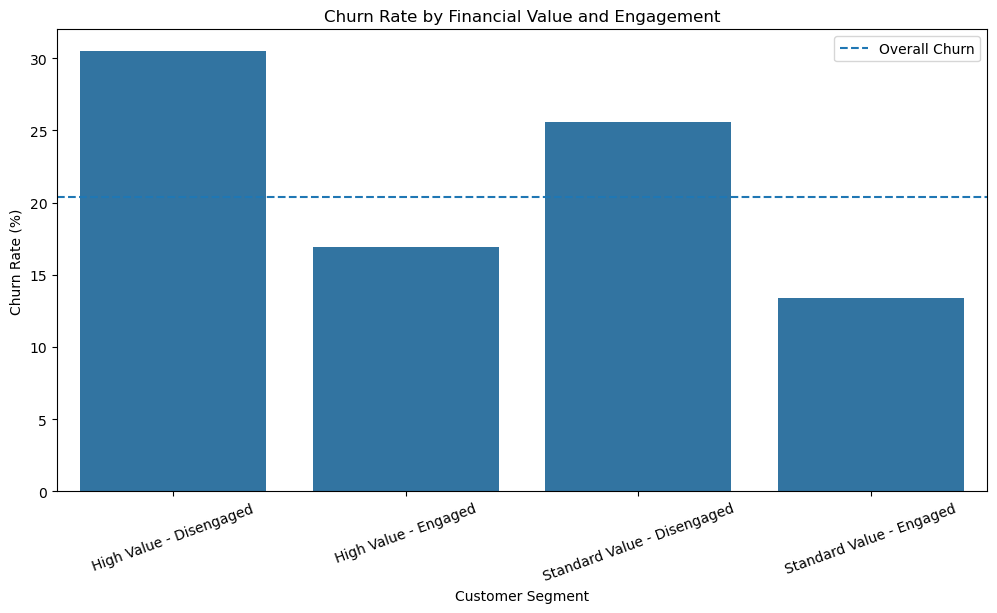

In [12]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=value_engagement_summary,
    x="Customer_Value_Segment",
    y="Churn_Rate"
)

plt.axhline(
    df["Exited"].mean() * 100,
    linestyle="--",
    label="Overall Churn"
)

plt.title(
    "Churn Rate by Financial Value and Engagement"
)

plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)
plt.legend()

plt.show()

In [13]:
balance_activity = pd.crosstab(
    df["Balance_Value_Group"],
    df["Engagement_Status"]
)

balance_activity

Engagement_Status,Active,Inactive
Balance_Value_Group,,
High Balance,1253,1247
Standard Balance,3898,3602


In [14]:
balance_activity_pct = pd.crosstab(
    df["Balance_Value_Group"],
    df["Engagement_Status"],
    normalize="index"
) * 100

balance_activity_pct.round(2)

Engagement_Status,Active,Inactive
Balance_Value_Group,,
High Balance,50.12,49.88
Standard Balance,51.97,48.03


In [15]:
balance_activity_churn = (
    df.groupby(
        ["Balance_Value_Group", "Engagement_Status"]
    )
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Products=("NumOfProducts", "mean")
    )
    .reset_index()
)

balance_activity_churn["Churn_Rate"] *= 100

balance_activity_churn.round(2)

,Balance_Value_Group,Engagement_Status,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Products
0,High Balance,Active,1253,212,16.92,149243.04,1.39
1,High Balance,Inactive,1247,380,30.47,148857.68,1.38
2,Standard Balance,Active,3898,523,13.42,52291.63,1.58
3,Standard Balance,Inactive,3602,922,25.60,52304.02,1.57


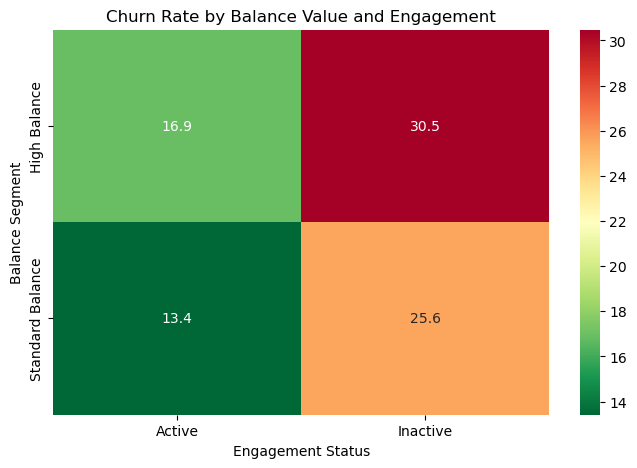

In [16]:
balance_activity_pivot = balance_activity_churn.pivot(
    index="Balance_Value_Group",
    columns="Engagement_Status",
    values="Churn_Rate"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    balance_activity_pivot,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r"
)

plt.title(
    "Churn Rate by Balance Value and Engagement"
)

plt.xlabel("Engagement Status")
plt.ylabel("Balance Segment")

plt.show()

In [17]:
high_value_watchlist = df[
    df["High_Value_Disengaged"] == 1
].copy()

In [18]:
watchlist_columns = [
    "CustomerId",
    "Surname",
    "Geography",
    "Gender",
    "Age",
    "CreditScore",
    "Balance",
    "EstimatedSalary",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "Exited",
    "Customer_Value_Segment",
    "Final_Engagement_Segment"
]

high_value_watchlist[
    watchlist_columns
].head(20)

,CustomerId,Surname,Geography,Gender,Age,CreditScore,Balance,EstimatedSalary,NumOfProducts,HasCrCard,IsActiveMember,Exited,Customer_Value_Segment,Final_Engagement_Segment
2,15619304,Onio,France,Female,42,502,159660.80,113931.57,3,1,0,1,High Value - Disengaged,Complex / Investigate
16,15737452,Romeo,Germany,Male,58,653,132602.88,5097.67,1,1,0,1,High Value - Disengaged,Disengaged Single-Product
35,15794171,Lombardo,France,Female,45,475,134264.04,27822.99,1,1,0,1,High Value - Disengaged,Disengaged Single-Product
43,15755196,Lavine,France,Female,49,834,131394.56,194365.76,1,0,0,1,High Value - Disengaged,Disengaged Single-Product
51,15768193,Trevisani,Germany,Male,36,585,146050.97,86424.57,2,0,0,0,High Value - Disengaged,Dormant Relationship
56,15630053,Tsao,France,Male,45,656,127864.40,87107.57,1,1,0,0,High Value - Disengaged,Disengaged Single-Product
60,15651280,Hunter,Germany,Male,35,742,136857.00,84509.57,1,0,0,0,High Value - Disengaged,Disengaged Single-Product
61,15773469,Clark,Germany,Female,27,687,152328.88,126494.82,2,0,0,0,High Value - Disengaged,Dormant Relationship
70,15703793,Konovalova,Germany,Male,58,738,133745.44,28373.86,4,1,0,1,High Value - Disengaged,Complex / Investigate
75,15780961,Cavenagh,France,Female,21,735,178718.19,22388.00,2,1,0,0,High Value - Disengaged,Dormant Relationship


In [19]:
watchlist_summary = {
    "Customers": len(high_value_watchlist),
    "Average Balance": high_value_watchlist["Balance"].mean(),
    "Average Salary": high_value_watchlist["EstimatedSalary"].mean(),
    "Average Products": high_value_watchlist["NumOfProducts"].mean(),
    "Churn Rate": high_value_watchlist["Exited"].mean() * 100
}

pd.Series(watchlist_summary).round(2)

Customers             1247.00
Average Balance     148857.68
Average Salary      101338.72
Average Products         1.38
Churn Rate              30.47
dtype: float64

In [20]:
high_balance_activity = (
    high_balance_customers
    .groupby("Engagement_Status")
    .agg(
        Customers=("CustomerId", "count"),
        Churn_Rate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Products=("NumOfProducts", "mean")
    )
    .reset_index()
)

high_balance_activity["Churn_Rate"] *= 100

high_balance_activity.round(2)

,Engagement_Status,Customers,Churn_Rate,Avg_Balance,Avg_Products
0,Active,1253,16.92,149243.04,1.39
1,Inactive,1247,30.47,148857.68,1.38


In [21]:
balance_churn_comparison = (
    df.groupby("Churn_Status")
    .agg(
        Customers=("CustomerId", "count"),
        Average_Balance=("Balance", "mean"),
        Median_Balance=("Balance", "median"),
        Average_Salary=("EstimatedSalary", "mean"),
        Average_Products=("NumOfProducts", "mean")
    )
    .reset_index()
)

balance_churn_comparison.round(2)

,Churn_Status,Customers,Average_Balance,Median_Balance,Average_Salary,Average_Products
0,Churned,2037,91108.54,109349.29,101465.68,1.48
1,Retained,7963,72745.30,92072.68,99738.39,1.54


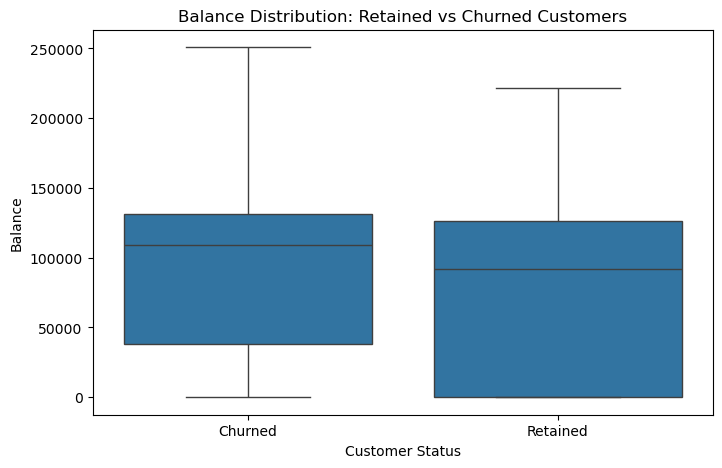

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn_Status",
    y="Balance"
)

plt.title(
    "Balance Distribution: Retained vs Churned Customers"
)

plt.xlabel("Customer Status")
plt.ylabel("Balance")

plt.show()

In [23]:
salary_balance_analysis = (
    df.groupby("Financial_Segment")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Salary=("EstimatedSalary", "mean"),
        Active_Rate=("IsActiveMember", "mean")
    )
    .reset_index()
)

salary_balance_analysis["Churn_Rate"] *= 100
salary_balance_analysis["Active_Rate"] *= 100

salary_balance_analysis.round(2)

,Financial_Segment,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Salary,Active_Rate
0,High Salary - High Balance,2516,631,25.08,131071.01,149895.20,50.99
1,High Salary - Low Balance,2484,411,16.55,22623.08,149636.48,51.53
2,Low Salary - High Balance,2484,618,24.88,130994.86,50693.98,50.76
3,Low Salary - Low Balance,2516,377,14.98,21262.83,50137.21,52.74


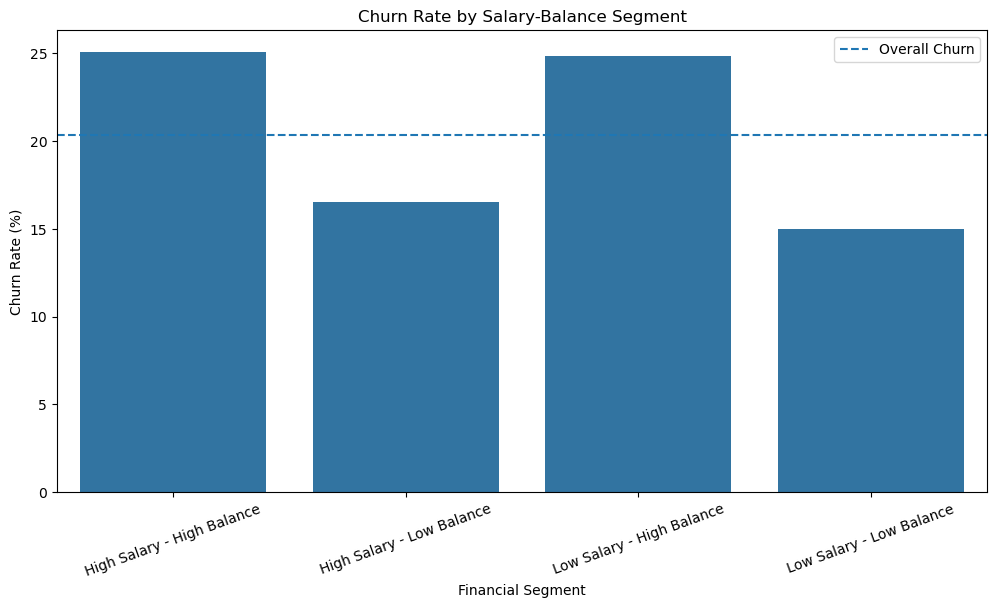

In [24]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=salary_balance_analysis,
    x="Financial_Segment",
    y="Churn_Rate"
)

plt.axhline(
    df["Exited"].mean() * 100,
    linestyle="--",
    label="Overall Churn"
)

plt.title(
    "Churn Rate by Salary-Balance Segment"
)

plt.xlabel("Financial Segment")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)
plt.legend()

plt.show()

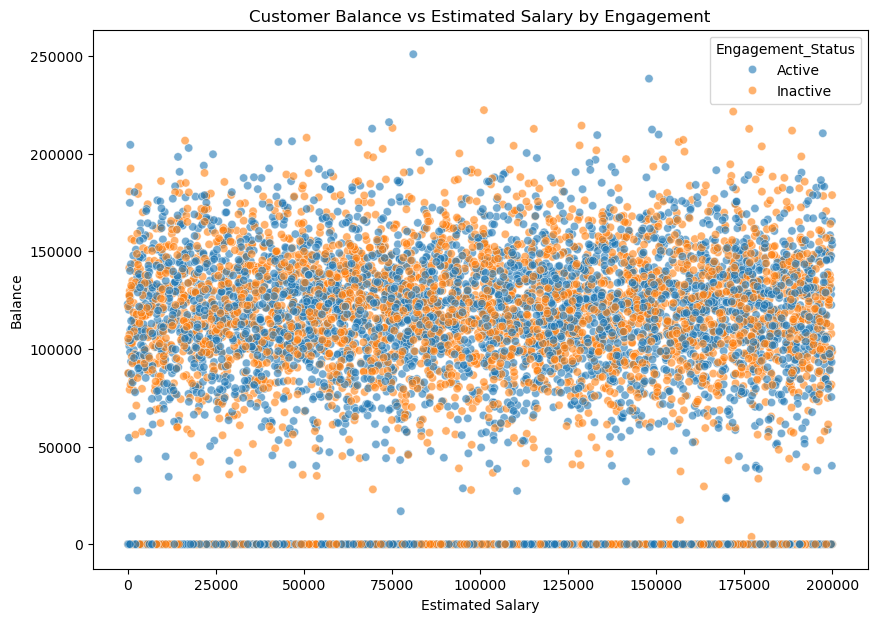

In [25]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="EstimatedSalary",
    y="Balance",
    hue="Engagement_Status",
    alpha=0.6
)

plt.title(
    "Customer Balance vs Estimated Salary by Engagement"
)

plt.xlabel("Estimated Salary")
plt.ylabel("Balance")

plt.show()

In [26]:
at_risk_premium = df[
    (df["Balance"] >= high_balance_threshold) &
    (df["IsActiveMember"] == 0)
].copy()

In [27]:
premium_metrics = pd.DataFrame({
    "Metric": [
        "Customers",
        "Churn Rate",
        "Average Balance",
        "Average Salary",
        "Average Products"
    ],
    "Value": [
        len(at_risk_premium),
        at_risk_premium["Exited"].mean() * 100,
        at_risk_premium["Balance"].mean(),
        at_risk_premium["EstimatedSalary"].mean(),
        at_risk_premium["NumOfProducts"].mean()
    ]
})

premium_metrics.round(2)

,Metric,Value
0,Customers,1247.00
1,Churn Rate,30.47
2,Average Balance,148857.68
3,Average Salary,101338.72
4,Average Products,1.38


In [28]:
premium_product = (
    at_risk_premium
    .groupby("Product_Depth_Group")
    .agg(
        Customers=("CustomerId", "count"),
        Churn_Rate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean")
    )
    .reset_index()
)

premium_product["Churn_Rate"] *= 100

premium_product.round(2)

,Product_Depth_Group,Customers,Churn_Rate,Avg_Balance
0,3+ Products,49,100.00,146825.29
1,Single Product,828,33.45,148699.78
2,Two Products,370,14.59,149480.19


In [29]:
def premium_risk(row):
    
    if (
        row["Balance"] >= high_balance_threshold
        and row["IsActiveMember"] == 0
        and row["NumOfProducts"] == 1
    ):
        return "Critical Premium Risk"
    
    elif (
        row["Balance"] >= high_balance_threshold
        and row["IsActiveMember"] == 0
    ):
        return "High Premium Risk"
    
    elif (
        row["Balance"] >= high_balance_threshold
        and row["IsActiveMember"] == 1
    ):
        return "High Value Engaged"
    
    else:
        return "Standard Customer"

df["Premium_Risk_Category"] = df.apply(
    premium_risk,
    axis=1
)

In [30]:
df["Premium_Risk_Category"].value_counts()

Premium_Risk_Category
Standard Customer        7500
High Value Engaged       1253
Critical Premium Risk     828
High Premium Risk         419
Name: count, dtype: int64

In [31]:
premium_risk_analysis = (
    df.groupby("Premium_Risk_Category")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Products=("NumOfProducts", "mean")
    )
    .reset_index()
)

premium_risk_analysis["Churn_Rate"] *= 100

premium_risk_analysis.sort_values(
    "Churn_Rate",
    ascending=False
).round(2)

,Premium_Risk_Category,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Products
0,Critical Premium Risk,828,277,33.45,148699.78,1.00
1,High Premium Risk,419,103,24.58,149169.72,2.14
3,Standard Customer,7500,1445,19.27,52297.58,1.58
2,High Value Engaged,1253,212,16.92,149243.04,1.39


In [32]:
df["Premium_Risk_Score"] = (
    (df["Balance"] >= high_balance_threshold).astype(int) * 40
    + (df["IsActiveMember"] == 0).astype(int) * 30
    + (df["NumOfProducts"] == 1).astype(int) * 20
    + (df["HasCrCard"] == 0).astype(int) * 10
)

In [33]:
df["Premium_Risk_Score"].describe()

count    10000.000000
mean        37.660000
std         26.798437
min          0.000000
25%         20.000000
50%         30.000000
75%         60.000000
max        100.000000
Name: Premium_Risk_Score, dtype: float64

In [34]:
def risk_band(score):
    
    if score >= 80:
        return "Critical"
    
    elif score >= 60:
        return "High"
    
    elif score >= 40:
        return "Medium"
    
    else:
        return "Low"

df["Premium_Risk_Band"] = (
    df["Premium_Risk_Score"]
    .apply(risk_band)
)

In [35]:
df["Premium_Risk_Band"].value_counts()

Premium_Risk_Band
Low         5243
Medium      2207
High        1603
Critical     947
Name: count, dtype: int64

In [36]:
risk_validation = (
    df.groupby("Premium_Risk_Band")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Actual_Churn_Rate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Products=("NumOfProducts", "mean")
    )
    .reset_index()
)

risk_validation["Actual_Churn_Rate"] *= 100

risk_validation.round(2)

,Premium_Risk_Band,Customers,Churned,Actual_Churn_Rate,Avg_Balance,Avg_Products
0,Critical,947,309,32.63,148760.01,1.14
1,High,1603,388,24.20,127156.33,1.21
2,Low,5243,718,13.69,47444.64,1.71
3,Medium,2207,622,28.18,77661.68,1.50


In [37]:
management_watchlist = (
    df[
        df["Premium_Risk_Score"] >= 60
    ][
        [
            "CustomerId",
            "Surname",
            "Geography",
            "Age",
            "Balance",
            "EstimatedSalary",
            "NumOfProducts",
            "HasCrCard",
            "IsActiveMember",
            "Exited",
            "Premium_Risk_Score",
            "Premium_Risk_Band"
        ]
    ]
    .sort_values(
        "Premium_Risk_Score",
        ascending=False
    )
)

management_watchlist.head(25)

,CustomerId,Surname,Geography,Age,Balance,EstimatedSalary,NumOfProducts,HasCrCard,IsActiveMember,Exited,Premium_Risk_Score,Premium_Risk_Band
2554,15739357,Moss,Spain,30,145127.85,7554.68,1,0,0,0,100,Critical
4069,15656613,McGregor,France,34,131283.11,130500.65,1,0,0,0,100,Critical
1968,15693468,Simmons,Spain,39,140553.46,12440.44,1,0,0,0,100,Critical
7316,15811690,Bayley,Germany,54,128966.13,18633.40,1,0,0,1,100,Critical
4024,15758073,Dellucci,France,20,134397.61,28029.54,1,0,0,0,100,Critical
841,15737792,Abbie,France,31,186796.37,178252.63,1,0,0,0,100,Critical
840,15707567,Esposito,Germany,50,145338.76,91936.10,1,0,0,1,100,Critical
7328,15689786,Massie,Germany,56,169743.83,155850.40,1,0,0,1,100,Critical
3973,15669281,Ch'iu,Spain,38,128718.78,114793.45,1,0,0,0,100,Critical
821,15716155,Shaw,France,36,156021.31,122662.98,1,0,0,0,100,Critical


In [38]:
df.to_csv(
    "European_Bank_Financial_Engagement_Analyzed.csv",
    index=False
)

print(
    "✅ Step 5 dataset saved successfully."
)

✅ Step 5 dataset saved successfully.


In [39]:
value_engagement_summary.to_csv(
    "Financial_Engagement_Summary.csv",
    index=False
)

premium_risk_analysis.to_csv(
    "Premium_Risk_Analysis.csv",
    index=False
)

management_watchlist.to_csv(
    "Premium_Customer_Watchlist.csv",
    index=False
)